# iprPy grain_boundary_static calculation

In [1]:
# Standard library imports
import datetime
from copy import deepcopy

# http://www.numpy.org/
import numpy as np

import matplotlib.pyplot as plt

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-07-08 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('grain_boundary_static')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# grain_boundary_static calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The grain_boundary_static calculation style constructs and evaluates grain boundary structures and energies for a given grain boundary orientation by performing only static energy/force relaxations.  Each calculation performs multiple grain boundary structure relaxations in a search for the in- and out-of plane shifts that produce the lowest energy structure. 

### Version notes

- v0.??.?: Calculation method created by combining and generalizing the previous grain_boundary_search and grain_boundary_bcc methods.
- v0.11.?: Calculation method updated to be consistent with the new grain_boundary_grip method by using small non-periodic atomic configurations.
- v0.12.0: Method updated to support the LAMMPS library interface.
  
### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)



## Method and Theory

### Grain boundary orientations and configurations
This method attempts to find a low energy grain boundary configuration by statically relaxing multiple grain boundary configurations.

A grain boundary orientation is defined based on a crystal unit cell and orientations of the two grains. The two grains are constructed by replicating and rotating the unit cell according to the defined orientations. However, grain orientation alone does not uniquely define a grain boundary configuration as the two grains can be rigidly shifted with respect to each other and with respect to where the grain boundary plane cleaves the grains. This calculation method explores a variety of grain boundary configurations for a given orientation by 

1. Selecting rigid body shifts from vectors in the grain boundary plane to apply to one grain with respect to the other.  These vectors are identified by finding two non-parallel lattice vectors in the grain boundary plane, then constructing a 2D map of fractional coordinates of those two vectors to explore.
2. Out-of-plane positioning is explored by deleting atoms that have neighbors in the opposite grain less than some cutoff distance. For each in-plane shift, multiple deletion cutoffs are iterated over, and the resulting configuration is only relaxed if it differs from the previous explored cutoff (i.e. additional atoms were deleted).

This sampling explores a wide range of configurations, but is not guaranteed to be complete or comprehensive. The configuration search still generates (mostly) cleanly cleaved interfaces, and the static-only relaxation does not allow for substantial atomic reconfigurations. For better configuration exploration, see the grain_boundary_grip calculation method.

### System design

All grain boundary configurations are periodic along the two shortest in-plane lattice vectors and non-periodic perpendicular to the grain boundary plane. The atoms near the non-periodic free surface are constrained: all atoms in one boundary are held fixed, and all atoms in the other boundary move as a rigid block. All atoms in between the two surface boundaries are allowed to freely relax from the energy/force minimization.  Typically, the relaxation region is 40 Angstroms wide (20 Angstroms per grain), and the boundary regions are each at least 10 Angstroms wide.

## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "grain_boundary_static.py"

# Python script created by Lucas Hale

# Standard library imports
from pathlib import Path
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np
import numpy.typing as npt

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat, lammps
from atomman.lammps import LAMMPS, LAMMPSobj

def grain_boundary_static(lammps_command: Union[str, LAMMPSobj],
                          ucell: am.System,
                          potential: lammpspotential,
                          uvws1: npt.ArrayLike,
                          uvws2: npt.ArrayLike,
                          potential_energy: unitfloat,
                          mpi_command: Optional[str] = None,
                          conventional_setting: str = 'p',
                          cutboxvector: str = 'c',
                          gbwidth: unitfloat = '20 angstrom',
                          boundarywidth: unitfloat = '10 angstrom',
                          num_a1: int = 8,
                          num_a2: int = 8,
                          deletefrom: str = 'top',
                          min_deleter = 0.30,
                          max_deleter = 0.99,
                          num_deleter = 100,
                          etol: float = 1e-15,
                          ftol: unitfloat = '1e-15 eV/atom',
                          maxiter: int = 100000,
                          maxeval: int = 1000000,
                          dmax: unitfloat = '0.01 angstrom',
                          alldump: bool = True,
                          usefiles: bool = False) -> dict:
    """
    Evaluates the energy of a grain boundary by building a two grain system and
    statically relaxing a range of atomic configurations that iterate over
    planar shifts and inter-planar atomic deletion.

    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    ucell : atomman.System
        The crystal unit cell to use as the basis of the grain boundary
        configurations.
    potential : PotentialLAMMPS or PotentialLAMMPSKIM
        The LAMMPS implemented potential to use.
    uvws1 : array-like object
        The Miller(-Bravais) crystal vectors associated with rotating ucell to
        form the 'top' grain.
    uvws2 : array-like object
        The Miller(-Bravais) crystal vectors associated with rotating ucell to
        form the 'bottom' grain.
    potential_energy : float, optional
        The per-atom potential energy of the bulk crystal to use for the grain
        boundary energy calculation.  This is currently limited to a single
        value so it only works with elemental systems.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel.  If not given, LAMMPS
        will run serially.
    cutboxvector : str, optional
        Indicates which of the three system box vectors, 'a', 'b', or 'c', is
        out-of-plane with the grain boundary (default is 'c').
    conventional_setting : str, optional
        Specifies the cell setting for ucell if it is a non-primitive unit cell.
        This is used in generating the boundary configuration and determining
        the smallest out-of-plane lattice vector component.
    gbwidth : float, optional
        The width of the region around the grain boundary that will be relaxed.
        Note that the region itself will be twice as thick as gbwidth as it is
        applied to both crystals independently.  Default value is 20 angstroms.
    boundarywidth : float, optional
        The minimum width of the boundary region beyond the gbwidth where
        atoms exist but are not subjected to relaxation. This region prevents
        the other atoms from seeing a free surface.  Default value is 10
        angstroms.
    num_a1 : int, optional
        The number of in-plane shif

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 4'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial unit cell system

- __ucell__ is an atomman.System representing a fundamental unit cell of the system (required).  Here, this is generated by loading the relaxed fcc crystal for the potential from the database.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Create ucell by loading prototype record
ucell = am.load('crystal', potential=potential, family='A1--Cu--fcc')

print(ucell)

Multiple matching record retrieved from remote
#  family               symbols  alat    Ecoh    method  standing
 1 A1--Cu--fcc          Ni        3.5200 -4.4500 dynamic good
 2 A1--Cu--fcc          Ni        7.3760  0.0119 dynamic good


Please select one: 1


avect =  [ 3.520,  0.000,  0.000]
bvect =  [ 0.000,  3.520,  0.000]
cvect =  [ 0.000,  0.000,  3.520]
origin = [ 0.000,  0.000,  0.000]
natoms = 4
natypes = 1
symbols = ('Ni',)
pbc = [ True  True  True]
per-atom properties = ['atype', 'pos']
     id |   atype |  pos[0] |  pos[1] |  pos[2]
      0 |       1 |   0.000 |   0.000 |   0.000
      1 |       1 |   0.000 |   1.760 |   1.760
      2 |       1 |   1.760 |   0.000 |   1.760
      3 |       1 |   1.760 |   1.760 |   0.000


### 3.4 Defect parameters

- __uvws1__: The three miller vectors with respect to the given unit cell that specify how the top grain is to be oriented.
- __uvws2__: The three miller vectors with respect to the given unit cell that specify how the bottom grain is to be oriented.
- __conventional_setting__: If the given unit cell is a conventional cell, specifying this allows for the algorithms to find lattice vectors with fractional coordinates.  Recognized values are 'p' primitive (default), 'f' face-centered, 'i' body-centered, 'a', 'b', 'c' side-centered. 
- __cutboxvector__: Indicates which box vector 'a', 'b', or 'c' the grain boundary plane intersects. Default value is 'c'.

In [9]:
# Grain orientations for fcc <100> symmetric tilt with 53.13 misorientation
uvws1 = np.array([[ 0, 0, 1], [ 2, 1, 0], [-1, 2, 0]])            
uvws2 = np.array([[ 0, 0, 1], [ 2,-1, 0], [ 1, 2, 0]])
conventional_setting = 'f'
cutboxvector = 'c'

### 3.5 Calculation-specific parameters

- __potential_energy__ is the per-atom potential energy of the bulk crystal to use for the grain boundary energy calculation.  This is currently limited to a single value so it only works with elemental systems.
- __gbwidth__ is the width of the region nearest the grain boundary where the atoms will be allowed to relax.  Note that this width is separately applied to both grains, so the total width of the relaxation region is twice this value.  Default value is 20 angstrom.
- __boundarywidth__ is the width to use for the constrained boundary regions outside of the gb relaxation region.  Default value is 10 angstrom. 
- __num_a1__ indicates how many grid shifts to explore along the first in-plane lattice vector.  Default value is 8.
- __num_a2__ indicates how many grid shifts to explore along the second in-plane lattice vector.  Default value is 8.
- __deletefrom__ indicates which of the two grains 'top' or 'bottom' that the close boundary atoms are to be deleted from.  A value of 'both' will independently iterate over both top and bottom deletions.  Default value is 'top'.
- __min_deleter__ is the minimum interatomic distance to use for identifying atoms to delete based on being within this distance from other atoms across the grain boundary.  Values are taken as relative to the ucell's r0.  Default value is 0.3.
- __max_deleter__ is the maximum interatomic distance to use for identifying atoms to delete based on being within this distance from other atoms across the grain boundary.  Values are taken as relative to the ucell's r0.  Default value is 0.99.
- __num_deleter__ is the number of interatomic distances to use for identifying atoms to delete based on being close to others across the grain boundary.  Note that only unique configurations will be relaxed, so this value sets the max number of configurations per a1,a2 shift that will be explored through atom deletion.  Default value is 100.
- __alldump__ is a boolean flag, where True (default) indicates all dump files for the relaxed configurations are retained, while False deletes the higher energy dump files as the calculation proceeds so that only the lowest energy structure is retained.
- __etol__ is the energy tolerance to use during the minimizations. This is unitless.
- __ftol__ is the force tolerance to use during the minimizations. This is in energy/length units.
- __maxiter__ is the maximum number of minimization iterations to use.
- __maxeval__ is the maximum number of minimization evaluations to use.
- __dmax__ is the largest distance that an atom is allowed to move during a minimization iteration. This is in length units.

In [10]:
potential_energy = -4.4500
gbwidth = 20
boundarywidth = 10
num_a1 = 8
num_a2 = 8
deletefrom = 'top'
min_deleter = 0.3
max_deleter = 0.99
num_deleter = 100
alldump = True
etol = 1e-8
ftol = uc.set_in_units(0.0, 'eV/angstrom')
maxiter = 10000
maxeval = 100000
dmax = uc.set_in_units(0.01, 'angstrom')

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [11]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.grain_boundary_static.grain_boundary_static'

In [12]:
results_dict = calculation.calc(lammps_command, ucell, potential,
                                uvws1, uvws2, potential_energy,
                                mpi_command = mpi_command,
                                conventional_setting = conventional_setting,
                                cutboxvector = cutboxvector,
                                gbwidth = gbwidth,
                                boundarywidth = boundarywidth,
                                num_a1 = num_a1,
                                num_a2 = num_a2,
                                deletefrom = deletefrom,
                                min_deleter = min_deleter,
                                max_deleter = max_deleter,
                                num_deleter = num_deleter,
                                alldump = alldump,
                                etol = etol,
                                ftol = ftol,
                                maxiter = maxiter,
                                maxeval = maxeval,
                                dmax = dmax)
print(results_dict.keys())

dict_keys(['gb_energies', 'min_gb_energy', 'dumpfile_final', 'symbols_final'])


### 4.2. Report results

Values returned in the results_dict:

- **'gb_energies'** (*list*) - All of the measured grain boundary energies of the relaxed configurations.
- **'min_gb_energy'** (*float*) - The lowest grain boundary energy found.
- **'dumpfile_final'** (*atomman.System*) - The name of the dump file associated wiht the lowest grain boundary energy.
- **'symbols_final'** (*list*) - The element model symbos for the dump file.


In [13]:
energy_per_area_unit = 'eV/angstrom^2'

print('Minimum E_gb =', uc.get_in_units(results_dict['min_gb_energy'], energy_per_area_unit), energy_per_area_unit)

Minimum E_gb = 0.09762403541717324 eV/angstrom^2


In [14]:
print(f'All E_gbs ({energy_per_area_unit}) =')
print(uc.get_in_units(results_dict['gb_energies'], energy_per_area_unit))

All E_gbs (eV/angstrom^2) =
[0.0976271  0.09762448 0.10587458 0.097627   0.09763044 0.10588083
 0.0976484  0.1066934  0.10587507 0.1058804  0.09762544 0.18005829
 0.09762825 0.10668348 0.09763631 0.10587707 0.12797642 0.10589576
 0.1058849  0.09762502 0.18005827 0.09764437 0.10588309 0.10587765
 0.10240065 0.10587651 0.10238898 0.09762619 0.0976298  0.10588565
 0.1058757  0.10239076 0.10647658 0.09762722 0.09762474 0.09762413
 0.12798265 0.10588501 0.0976309  0.09762485 0.10587856 0.14612232
 0.10588468 0.10587736 0.12798211 0.10587638 0.09762671 0.18005382
 0.09763293 0.09763009 0.10588517 0.09763887 0.10588061 0.12797395
 0.10588044 0.0976248  0.18006163 0.09764031 0.12798387 0.10588482
 0.10239382 0.10588533 0.10239184 0.09762949 0.10587883 0.09762555
 0.10588044 0.10588367 0.10239513 0.10646692 0.09763864 0.10589031
 0.09762752 0.09762724 0.09762765 0.10587935 0.10587927 0.09762978
 0.10589173 0.10588138 0.09763264 0.10587501 0.10588852 0.10587997
 0.1064643  0.09764074 0.10588016 

In [15]:
# Load dump file
gb_system = am.load('atom_dump', results_dict['dumpfile_final'],
                    symbols = results_dict['symbols_final'])

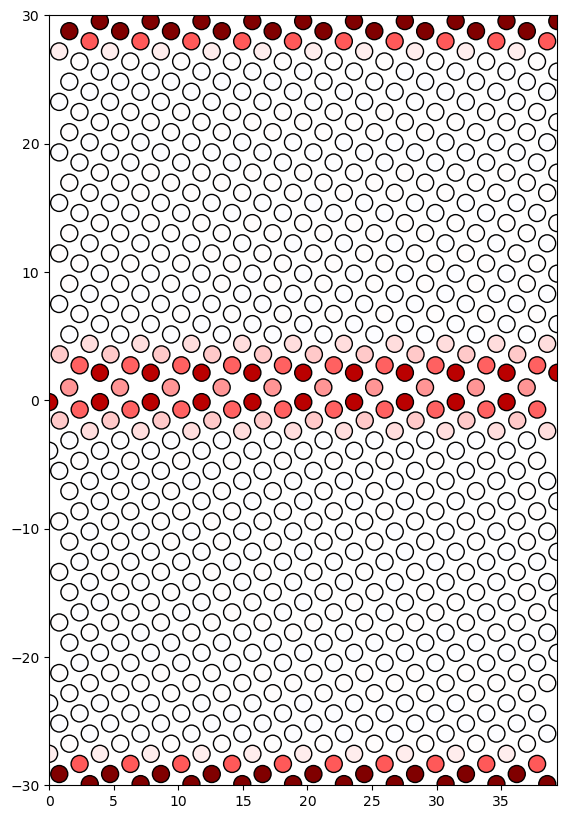

In [16]:
# Create projection plot along the <100> tilt axis

# Get system's original b lattice vector (a.k.a. ymax)
ymax = gb_system.box.b

# Wrap atoms, supersize and get y, z, and pe 
gb_system.wrap()
y = gb_system.atoms.pos[:, 1]
z = gb_system.atoms.pos[:, 2]
pe = gb_system.atoms.c_peatom

# Init figure with width scaled to ymax (height is 10 for 60 Angstroms)
fig = plt.figure(figsize=(ymax / 6, 10))  

plt.scatter(y, z, s=150, c=pe, vmin=potential_energy-0.5, vmax=potential_energy+0.5, cmap='seismic', edgecolors='k')
plt.xlim(0, ymax)
plt.ylim(-30, 30)

plt.show()

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [17]:
calculation.clean_files()